# 05 - Asignación espacial de estaciones a embalses

Determina, para cada embalse, qué estaciones de medida guardan relación con él, de cara
a la construcción del dataset de modelado.

## Criterios

- **Estaciones de calidad e hidrológicas**: relación de drenaje derivada de la topología
  de la red fluvial. Para las de calidad se admiten ambas direcciones; para las
  hidrológicas, únicamente aguas arriba.
- **Estaciones meteorológicas**: proximidad geográfica, al no seguir estas variables la
  red de drenaje.

## Salidas

- `asignacion_calidad_embalses.parquet`
- `asignacion_hidro_embalses.parquet`
- `asignacion_meteo_embalses.parquet`
- `cobertura_embalses.parquet`

## 1. Configuración

In [1]:
import sys
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from shapely.geometry import Point

sys.path.append("..")
from src.saih import PATRON_COL, id_estacion, normalizar_id_embalse

DIR_RAW = Path("../data/raw")
DIR_EXTERNAL = Path("../data/external")
DIR_PROCESSED = Path("../data/processed")
DIR_FIGURAS = Path("../outputs/figures")

CRS_PROYECTO = "EPSG:25829"
DIR_CARTO = DIR_EXTERNAL / "Datos-Cartograficos-Plan-Hidrologico-2022-2027"

# Distancia máxima admitida entre embalse y estación (ver apartado 5)
UMBRAL_KM = 30

HOJAS = [
    ("Datos_Embalses.xlsx", "Datos_Embalses"),
    ("Datos_Estaciones.xlsx", "Datos_Nivel"),
    ("Datos_Estaciones.xlsx", "Datos_Caudal"),
    ("Datos_Estaciones.xlsx", "Datos_Precipitación"),
    ("Datos_Estaciones.xlsx", "Datos_TempAmb"),
    ("Datos_Estaciones_Calidad.xlsx", "Datos_Calidad"),
]

maestro = pd.read_parquet(DIR_PROCESSED / "maestro_embalses.parquet")

## 2. Capa de estaciones y embalses

Se construye una capa geográfica con las estaciones presentes en los datos y sus coordenadas. Las estaciones ubicadas en embalses emplean en las hojas de datos una codificación de tres dígitos (`E016A`) frente a la de dos dígitos más letra de las hojas de identificación (`E16A`), por lo que la correspondencia se establece normalizando el identificador y conservando el sufijo, que es lo que distingue instalaciones distintas de un mismo embalse.

In [2]:
def cargar_identificacion(fichero):
    """Hoja de identificación de estaciones, con cabecera de dos niveles."""
    df = pd.read_excel(DIR_RAW / "saih" / fichero,
                       sheet_name="Identificación Estaciones", skiprows=[1])
    df.columns = ["ID", "Nombre", "Municipio", "Provincia", "Sistema", "X", "Y"]
    df["ID"] = df["ID"].astype(str).str.strip()
    return df[df["ID"].ne("nan")]

ident = pd.concat([
    cargar_identificacion("Datos_Estaciones.xlsx"),
    cargar_identificacion("Datos_Embalses.xlsx"),
], ignore_index=True).drop_duplicates(subset="ID")

ident["Sistema"] = ident["Sistema"].astype(str).str.strip().replace({"Sil Inf": "Sil Inferior"})
ident[["X", "Y"]] = ident[["X", "Y"]].apply(pd.to_numeric, errors="coerce")

print(f"Estaciones con coordenadas: {len(ident)}")

Estaciones con coordenadas: 115


In [3]:
TIPO_POR_HOJA = {
    "Datos_Embalses": "embalse",
    "Datos_Nivel": "nivel_rio",
    "Datos_Caudal": "caudal_rio",
    "Datos_Precipitación": "precipitacion",
    "Datos_TempAmb": "temp_ambiente",
    "Datos_Calidad": "calidad",
}

registros = []
for fichero, hoja in HOJAS:
    cols = pd.read_excel(DIR_RAW / "saih" / fichero, sheet_name=hoja, nrows=0).columns
    for est in {i for i in (id_estacion(c) for c in cols[1:]) if i}:
        registros.append({"id_datos": est, "tipo": TIPO_POR_HOJA[hoja]})

tipos = (pd.DataFrame(registros).drop_duplicates()
         .groupby("id_datos")["tipo"].apply(lambda s: sorted(s)).reset_index())

ids_ident = set(ident["ID"])

def resolver(id_datos):
    """Identificador de la hoja de identificación correspondiente, o None."""
    if id_datos in ids_ident:
        return id_datos
    norm = normalizar_id_embalse(id_datos)
    return norm if norm in ids_ident else None

tipos["ID"] = tipos["id_datos"].apply(resolver)
print(f"Sin correspondencia: {sorted(tipos.loc[tipos['ID'].isna(), 'id_datos'])}")

tipos_con_coords = tipos.dropna(subset=["ID"]).merge(ident, on="ID", how="left")

estaciones_gdf = gpd.GeoDataFrame(
    tipos_con_coords,
    geometry=gpd.points_from_xy(tipos_con_coords["X"], tipos_con_coords["Y"]),
    crs=CRS_PROYECTO,
)

es_embalse = estaciones_gdf["tipo"].apply(lambda t: "embalse" in t)
embalses_gdf = estaciones_gdf[es_embalse].copy()
calidad_gdf = estaciones_gdf[estaciones_gdf["tipo"].apply(lambda t: "calidad" in t)].copy()

print(f"Embalses: {len(embalses_gdf)} | Estaciones de calidad: {len(calidad_gdf)}")

Sin correspondencia: ['A004', 'A021', 'E007B', 'E03S']
Embalses: 35 | Estaciones de calidad: 18


## 3. Criterios descartados

**Pertenencia a una unidad hidrográfica común.** 

**Superficie acumulada de drenaje.** 

In [4]:
subcuencas = gpd.read_file(DIR_CARTO / "Hidrografia" / "Subcuencas.shp").to_crs(CRS_PROYECTO)
vertientes = gpd.read_file(DIR_CARTO / "Masas_Agua" / "Cuencas_vertientes.shp").to_crs(CRS_PROYECTO)

es_embalse = estaciones_gdf["tipo"].apply(lambda t: "embalse" in t)
embalses_gdf = estaciones_gdf[es_embalse].copy()
medida_gdf = estaciones_gdf[~es_embalse].copy()

print(f"Embalses: {len(embalses_gdf)} | Estaciones de medida: {len(medida_gdf)}\n")

for nombre, gdf, col in [("Subcuencas", subcuencas, "COD_CUENCA"),
                         ("Cuencas vertientes", vertientes, "Cod_MSPF")]:
    emb = gpd.sjoin(embalses_gdf[["ID", "geometry"]], gdf[[col, "geometry"]],
                    how="left", predicate="within")
    est = gpd.sjoin(medida_gdf[["ID", "geometry"]], gdf[[col, "geometry"]],
                    how="left", predicate="within")

    conteo = (emb[["ID", col]]
              .merge(est[["ID", col]], on=col, how="left", suffixes=("_emb", "_est"))
              .groupby("ID_emb")["ID_est"].nunique()
              .reindex(embalses_gdf["ID"]).fillna(0))

    print(f"=== {nombre} ({len(gdf)} polígonos) ===")
    print(f"Estaciones por embalse -> mediana {conteo.median():.0f} | máx {conteo.max():.0f}")
    print(f"Embalses sin ninguna estación: {(conteo == 0).sum()} de {len(conteo)}\n")

conteo_sist = (embalses_gdf[["ID", "Sistema"]]
               .merge(medida_gdf[["ID", "Sistema"]], on="Sistema", how="left",
                      suffixes=("_emb", "_est"))
               .groupby("ID_emb")["ID_est"].nunique()
               .reindex(embalses_gdf["ID"]).fillna(0))

print("=== Sistema de explotación ===")
print(f"Estaciones por embalse -> mediana {conteo_sist.median():.0f} | máx {conteo_sist.max():.0f}")
print(f"Embalses sin ninguna estación: {(conteo_sist == 0).sum()} de {len(conteo_sist)}")

Embalses: 35 | Estaciones de medida: 85

=== Subcuencas (978 polígonos) ===
Estaciones por embalse -> mediana 0 | máx 1
Embalses sin ninguna estación: 24 de 35

=== Cuencas vertientes (286 polígonos) ===
Estaciones por embalse -> mediana 0 | máx 3
Embalses sin ninguna estación: 21 de 35

=== Sistema de explotación ===
Estaciones por embalse -> mediana 10 | máx 29
Embalses sin ninguna estación: 0 de 35


## 4. Criterio adoptado: topología de la red fluvial

La capa `CaucesEjes_1_50000.shp` incorpora la codificación jerárquica de cauces del CEDEX en el campo `CODPK`, que describe el camino completo desde la desembocadura hasta cada cauce indicando en cada nivel el punto kilométrico de la confluencia y la margen.


In [5]:
cauces = gpd.read_file(DIR_CARTO / "Hidrografia" / "CaucesEjes_1_50000.shp").to_crs(CRS_PROYECTO)
geom_por_codpk = cauces.set_index("CODPK").geometry.to_dict()

print(f"Tramos de cauce: {len(cauces)}")

Tramos de cauce: 878


### Verificación del sentido de digitalización

La posición de un punto sobre un cauce se obtiene por proyección, cuyo resultado se mide desde el vértice inicial de la línea. Se comprueba en qué extremo comienza la digitalización, contrastando la posición de la confluencia del Sil con el Miño obtenida por proyección frente al punto kilométrico declarado en el código del cauce.

In [6]:
# El SIL como ejemplo:
sil = cauces[cauces["CAUNOM"].str.strip().eq("SIL")]
print("=== SIL ===")
print(sil[["CAUNOM", "COD_CAUCE", "CODDECIMAL", "CODPK", "CAULONG"]].to_string(index=False))

# Sentido de digitalización: ¿el vértice inicial es desembocadura o cabecera?
mino = cauces[cauces["CAUNOM"].str.strip().eq("MIÑO")].iloc[0]
sil_geom = sil.iloc[0].geometry

# Punto de confluencia = extremo del Sil más cercano al Miño
extremos = [Point(sil_geom.coords[0]), Point(sil_geom.coords[-1])]
confluencia = min(extremos, key=lambda p: p.distance(mino.geometry))

pos = mino.geometry.project(confluencia)
print(f"\nLongitud del Miño: {mino.geometry.length/1000:.1f} km (campo CAULONG: {mino['CAULONG']/1000:.1f} km)")
print(f"Confluencia del Sil proyectada a {pos/1000:.1f} km del vértice inicial")
print(f"PK declarado en CODPK: 14548 -> {14548*10/1000:.1f} km si son decámetros")

=== SIL ===
CAUNOM COD_CAUCE CODDECIMAL          CODPK  CAULONG
   SIL   NO02610 1.4400.290 NO-4400-14548I 233998.0

Longitud del Miño: 315.2 km (campo CAULONG: 315.2 km)
Confluencia del Sil proyectada a 167.6 km del vértice inicial
PK declarado en CODPK: 14548 -> 145.5 km si son decámetros


In [7]:
def pk_confluencia(cauce_hijo, cauce_padre):
    """Distancia desde la desembocadura del cauce padre hasta la confluencia, en km."""
    extremos = [Point(cauce_hijo.geometry.coords[0]), Point(cauce_hijo.geometry.coords[-1])]
    conf = min(extremos, key=lambda p: p.distance(cauce_padre.geometry))
    return (cauce_padre.geometry.length - cauce_padre.geometry.project(conf)) / 1000

mino = cauces[cauces["CAUNOM"].str.strip().eq("MIÑO")].iloc[0]
sil = cauces[cauces["CAUNOM"].str.strip().eq("SIL")].iloc[0]

# Afluentes directos del Miño y del Sil, según prefijo de CODPK
for padre, nombre_padre in [(mino, "MIÑO"), (sil, "SIL")]:
    prefijo = padre["CODPK"] + "-"
    hijos = cauces[
        cauces["CODPK"].str.startswith(prefijo, na=False)
        & (cauces["CODPK"].str.count("-") == padre["CODPK"].count("-") + 1)
    ]
    print(f"=== Afluentes directos del {nombre_padre} ({len(hijos)}) ===")
    filas = []
    for _, h in hijos.iterrows():
        pk_declarado = int(h["CODPK"].split("-")[-1][:-1]) * 10 / 1000
        filas.append({
            "cauce": h["CAUNOM"],
            "pk_codpk_km": pk_declarado,
            "pk_geom_km": round(pk_confluencia(h, padre), 1),
        })
    df = pd.DataFrame(filas).sort_values("pk_codpk_km")
    df["desfase_km"] = (df["pk_geom_km"] - df["pk_codpk_km"]).round(1)
    print(df.head(12).to_string(index=False))
    print(f"Desfase: mediana {df['desfase_km'].median():.1f} km | "
          f"máx abs {df['desfase_km'].abs().max():.1f} km\n")

=== Afluentes directos del MIÑO (100) ===
            cauce  pk_codpk_km  pk_geom_km  desfase_km
         LAGOS DE         4.68         5.9         1.2
         CARVALLO         5.44         6.8         1.4
            TOLLO        10.05        11.2         1.1
    FABRICA DE LA        14.22        15.6         1.4
        BRAVOS DE        15.39        16.8         1.4
         PEGO DEL        15.68        17.0         1.3
     HOSPITAL DEL        18.57        20.0         1.4
     FURNIA DE LA        20.98        22.5         1.5
       LEIRIÑA DE        27.23        28.9         1.7
       SEIJAL DEL        28.68        30.3         1.6
            LOURO        30.07        31.7         1.6
FUENTE FERRERO DE        32.43        34.0         1.6
Desfase: mediana 2.7 km | máx abs 5.7 km

=== Afluentes directos del SIL (62) ===
              cauce  pk_codpk_km  pk_geom_km  desfase_km
       RIGUEIRO DEL         1.57         1.5        -0.1
               CABE         7.81         7.5   

In [8]:
# Enganches forzados: puntos situados junto a una confluencia que el criterio de
# mínima distancia asigna a un afluente en lugar de al cauce principal.
CORRECCIONES = {"N010": "MIÑO", "E023": "SIL"}

def enganchar(gdf, correcciones):
    """Asigna a cada punto su cauce y su posición en km desde la desembocadura."""
    filas = []
    for _, p in gdf.iterrows():
        cand = cauces
        if p["ID"] in correcciones:
            cand = cauces[cauces["CAUNOM"].str.strip().eq(correcciones[p["ID"]])]
        d = cand.distance(p.geometry)
        c = cand.loc[d.idxmin()]
        filas.append({
            "ID": p["ID"], "Nombre": p["Nombre"],
            "cauce": c["CAUNOM"].strip(), "codpk": c["CODPK"],
            "dist_cauce_m": round(d.min(), 1),
            "pos_km": (c.geometry.length - c.geometry.project(p.geometry)) / 1000,
        })
    return pd.DataFrame(filas)

emb_c = enganchar(embalses_gdf, CORRECCIONES)
cal_c = enganchar(calidad_gdf, CORRECCIONES)

print(f"Distancia máxima punto-cauce: {max(emb_c['dist_cauce_m'].max(), cal_c['dist_cauce_m'].max()):.0f} m")

Distancia máxima punto-cauce: 320 m


In [9]:
def pos_confluencia(codpk_hijo, codpk_padre):
    """Posición de la desembocadura del cauce hijo sobre el padre, en km desde la
    desembocadura de este último."""
    hijo, padre = geom_por_codpk[codpk_hijo], geom_por_codpk[codpk_padre]
    extremos = [Point(hijo.coords[0]), Point(hijo.coords[-1])]
    conf = min(extremos, key=lambda p: p.distance(padre))
    return (padre.length - padre.project(conf)) / 1000

def relacion(est, emb):
    """Relación de drenaje entre estación y embalse.

    'arriba' si el agua de la estación llega al embalse, 'abajo' si el agua del embalse
    llega a la estación, None si no existe conexión.
    """
    # Mismo cauce: decide la posición relativa a la desembocadura
    if est["codpk"] == emb["codpk"]:
        return "arriba" if est["pos_km"] > emb["pos_km"] else "abajo"

    # El cauce de la estación cuelga del cauce del embalse
    if est["codpk"].startswith(emb["codpk"] + "-"):
        rama = emb["codpk"] + "-" + est["codpk"][len(emb["codpk"]) + 1:].split("-")[0]
        if rama in geom_por_codpk and pos_confluencia(rama, emb["codpk"]) > emb["pos_km"]:
            return "arriba"
        return None

    # El cauce del embalse cuelga del cauce de la estación
    if emb["codpk"].startswith(est["codpk"] + "-"):
        rama = est["codpk"] + "-" + emb["codpk"][len(est["codpk"]) + 1:].split("-")[0]
        if rama in geom_por_codpk and pos_confluencia(rama, est["codpk"]) > est["pos_km"]:
            return "abajo"
        return None

    return None

In [10]:
coords_emb = embalses_gdf.set_index("ID").geometry.to_dict()
coords_cal = calidad_gdf.set_index("ID").geometry.to_dict()

pares = emb_c.merge(cal_c, how="cross", suffixes=("_emb", "_cal"))

pares["relacion"] = pares.apply(
    lambda r: relacion({"codpk": r["codpk_cal"], "pos_km": r["pos_km_cal"]},
                       {"codpk": r["codpk_emb"], "pos_km": r["pos_km_emb"]}), axis=1)
pares["dist_km"] = pares.apply(
    lambda r: coords_emb[r["ID_emb"]].distance(coords_cal[r["ID_cal"]]) / 1000, axis=1)

conectados = pares[pares["relacion"].notna()].copy()

print("Pares con conexión hidrológica:")
print(conectados["relacion"].value_counts().to_string())

print("\nCobertura según umbral de distancia:")
for u in [20, 30, 50, 100]:
    sub = conectados[conectados["dist_km"] <= u]
    print(f"  <= {u:>3} km -> {sub['ID_emb'].nunique():>2}/35 embalses "
          f"| con aguas arriba {sub[sub['relacion'] == 'arriba']['ID_emb'].nunique():>2}"
          f" | con aguas abajo {sub[sub['relacion'] == 'abajo']['ID_emb'].nunique():>2}")

Pares con conexión hidrológica:
relacion
abajo     79
arriba    62

Cobertura según umbral de distancia:
  <=  20 km -> 14/35 embalses | con aguas arriba  7 | con aguas abajo  9
  <=  30 km -> 22/35 embalses | con aguas arriba 11 | con aguas abajo 15
  <=  50 km -> 25/35 embalses | con aguas arriba 13 | con aguas abajo 20
  <= 100 km -> 34/35 embalses | con aguas arriba 14 | con aguas abajo 33


## 5. Umbral de distancia

La conexión hidrológica es condición necesaria pero no suficiente: la señal de una estación se diluye a medida que aumenta la distancia al embalse, por la incorporación de aportaciones intermedias y por la presencia de otros embalses que regulan el caudal.

Se adopta un umbral de 30 km (ampliarlo a 50 km incorpora únicamente tres embalses adicionales)

In [11]:
asignacion = (conectados[conectados["dist_km"] <= UMBRAL_KM]
              [["ID_emb", "Nombre_emb", "ID_cal", "Nombre_cal",
                "cauce_emb", "cauce_cal", "relacion", "dist_km"]]
              .sort_values(["ID_emb", "dist_km"])
              .reset_index(drop=True))

resumen = (asignacion.groupby(["ID_emb", "Nombre_emb"])
           .apply(lambda g: pd.Series({
               "n_arriba": (g["relacion"] == "arriba").sum(),
               "n_abajo": (g["relacion"] == "abajo").sum(),
               "estaciones": ", ".join(f"{r.ID_cal}({'↑' if r.relacion == 'arriba' else '↓'})"
                                       for r in g.itertuples()),
           }), include_groups=False)
           .reset_index())

sin_cobertura = sorted(set(emb_c["ID"]) - set(asignacion["ID_emb"]))
print(f"Embalses con cobertura: {len(resumen)} de {len(emb_c)}")
print(f"Sin cobertura: {sin_cobertura}\n")
print(resumen.to_string(index=False))

Embalses con cobertura: 22 de 35
Sin cobertura: ['E003', 'E014', 'E015', 'E017', 'E020', 'E021', 'E022', 'E05A', 'E16A', 'E16D', 'E18A', 'E19A', 'E36A']

ID_emb         Nombre_emb  n_arriba  n_abajo                         estaciones
  E001            Belesar         1        0                            N002(↑)
  E002          Os Peares         0        1                            N010(↓)
  E008  Fuente del Azufre         0        1                            N007(↓)
  E009        Montearenas         0        1                            N007(↓)
  E011         Peñarrubia         1        1                   N007(↑), Q123(↓)
  E013         San Martin         1        0                            Q123(↑)
  E023        Montefurado         1        0                            Q123(↑)
  E024          Sequeiros         1        0                            Q123(↑)
  E025      Leboreiro Mao         0        1                            N010(↓)
  E026         Edrada Mao         0        1  

## 6. Asignación de estaciones hidrológicas

Se aplica el mismo criterio topológico a las estaciones de nivel y caudal en río.

A diferencia de las de calidad, aquí solo se admiten las situadas **aguas arriba**. 

In [12]:
def gdf_por_tipo(tipo):
    return estaciones_gdf[estaciones_gdf["tipo"].apply(lambda t: tipo in t)].copy()

hidro_todas = (pd.concat([gdf_por_tipo("caudal_rio"), gdf_por_tipo("nivel_rio")])
               .drop_duplicates(subset="ID"))
hid_c = enganchar(hidro_todas, CORRECCIONES)

pares_hid = emb_c.merge(hid_c, how="cross", suffixes=("_emb", "_est"))
pares_hid["relacion"] = pares_hid.apply(
    lambda r: relacion({"codpk": r["codpk_est"], "pos_km": r["pos_km_est"]},
                       {"codpk": r["codpk_emb"], "pos_km": r["pos_km_emb"]}), axis=1)

coords_hid = hidro_todas.set_index("ID").geometry.to_dict()
pares_hid["dist_km"] = pares_hid.apply(
    lambda r: coords_emb[r["ID_emb"]].distance(coords_hid[r["ID_est"]]) / 1000, axis=1)

hid_asig = (pares_hid[(pares_hid["relacion"] == "arriba") &
                      (pares_hid["dist_km"] <= UMBRAL_KM)]
            [["ID_emb", "Nombre_emb", "ID_est", "Nombre_est",
              "cauce_emb", "cauce_est", "dist_km"]]
            .sort_values(["ID_emb", "dist_km"]).reset_index(drop=True))

print(f"Estaciones hidrológicas: {len(hid_c)}")
print(f"Embalses con estación aguas arriba: {hid_asig['ID_emb'].nunique()} de {len(emb_c)}")
print(f"Estaciones por embalse: mediana {hid_asig.groupby('ID_emb').size().median():.0f}, "
      f"máximo {hid_asig.groupby('ID_emb').size().max()}")

Estaciones hidrológicas: 60
Embalses con estación aguas arriba: 20 de 35
Estaciones por embalse: mediana 2, máximo 8


## 7. Asignación de estaciones meteorológicas

Las variables meteorológicas no siguen la red de drenaje, por lo que el criterio topológico no es aplicable. 
Se emplea un criterio de proximidad geográfica, con un radio de 25 km en torno a cada embalse. Se consideran conjuntamente las estaciones meteorológicas del SAIH (precipitación y temperatura ambiente) y las de AEMET.

In [13]:
RADIO_METEO_KM = 25
RADIO_MAXIMO_KM = 50
N_RESPALDO = 3

aemet_inv = pd.read_parquet(DIR_RAW / "aemet" / "inventario_estaciones_minosil.parquet")
aemet_gdf = gpd.GeoDataFrame(
    aemet_inv.rename(columns={"indicativo": "ID", "nombre": "Nombre"}),
    geometry=gpd.points_from_xy(aemet_inv["lon_dec"], aemet_inv["lat_dec"]),
    crs="EPSG:4326",
).to_crs(CRS_PROYECTO)
aemet_gdf["fuente"] = "AEMET"

meteo_saih = (pd.concat([gdf_por_tipo("precipitacion"), gdf_por_tipo("temp_ambiente")])
              .drop_duplicates(subset="ID").assign(fuente="SAIH"))

meteo_gdf = pd.concat([
    meteo_saih[["ID", "Nombre", "fuente", "geometry"]],
    aemet_gdf[["ID", "Nombre", "fuente", "geometry"]],
], ignore_index=True)

filas = []
avisos = []
for _, e in embalses_gdf.iterrows():
    for fuente in ["SAIH", "AEMET"]:
        sub = meteo_gdf[meteo_gdf["fuente"] == fuente]
        d = (sub.distance(e.geometry) / 1000).sort_values()
        dentro = d[d <= RADIO_METEO_KM]
        if len(dentro):
            seleccion, respaldo = dentro, False
        else:
            seleccion, respaldo = d[d <= RADIO_MAXIMO_KM].head(N_RESPALDO), True
            if not len(seleccion):
                avisos.append((e["ID"], fuente))
                continue
        for i, dist in seleccion.items():
            filas.append({"ID_emb": e["ID"], "Nombre_emb": e["Nombre"],
                          "ID_est": sub.at[i, "ID"], "Nombre_est": sub.at[i, "Nombre"],
                          "fuente": fuente, "dist_km": round(dist, 2),
                          "por_respaldo": respaldo})

meteo_asig = pd.DataFrame(filas).sort_values(["ID_emb", "fuente", "dist_km"]).reset_index(drop=True)

for emb, fuente in avisos:
    print(f"AVISO: {emb} sin estación {fuente} a menos de {RADIO_MAXIMO_KM} km")

n_aemet = meteo_asig[meteo_asig["fuente"] == "AEMET"]["ID_emb"].nunique()
print(f"Embalses con AEMET: {n_aemet} de {len(embalses_gdf)}")
print(f"Asignaciones por respaldo: {meteo_asig['por_respaldo'].sum()}")

print(f"Estaciones meteorológicas: {len(meteo_gdf)} "
      f"({(meteo_gdf['fuente'] == 'SAIH').sum()} SAIH + {(meteo_gdf['fuente'] == 'AEMET').sum()} AEMET)")
print(f"Embalses cubiertos: {meteo_asig['ID_emb'].nunique()} de {len(embalses_gdf)}")
print(f"Estaciones por embalse: mediana {meteo_asig.groupby('ID_emb').size().median():.0f}, "
      f"mínimo {meteo_asig.groupby('ID_emb').size().min()}")

Embalses con AEMET: 35 de 35
Asignaciones por respaldo: 6
Estaciones meteorológicas: 117 (93 SAIH + 24 AEMET)
Embalses cubiertos: 35 de 35
Estaciones por embalse: mediana 10, mínimo 5


## 8. Cuadro de cobertura y guardado

Se resume la disponibilidad de cada tipo de variable por embalse y se guardan las tres tablas de asignación, que constituyen la entrada del proceso de construcción del dataset unificado.

In [14]:
cal_arriba = set(asignacion.loc[asignacion["relacion"] == "arriba", "ID_emb"])
cal_abajo = set(asignacion.loc[asignacion["relacion"] == "abajo", "ID_emb"])

cob = emb_c[["ID", "Nombre"]].copy()
cob["hidro_arriba"] = cob["ID"].isin(hid_asig["ID_emb"])
cob["meteo"] = cob["ID"].isin(meteo_asig["ID_emb"])
cob["calidad_arriba"] = cob["ID"].isin(cal_arriba)
cob["calidad_abajo"] = cob["ID"].isin(cal_abajo)
cob["calidad"] = cob["calidad_arriba"] | cob["calidad_abajo"]
cob["completo"] = cob["hidro_arriba"] & cob["meteo"] & cob["calidad"]
cob = cob.merge(maestro[["ID_SAIH", "Capacidad_hm3"]],
                left_on="ID", right_on="ID_SAIH", how="left").drop(columns="ID_SAIH")

for nombre, df in [("asignacion_calidad_embalses", asignacion),
                   ("asignacion_hidro_embalses", hid_asig),
                   ("asignacion_meteo_embalses", meteo_asig),
                   ("cobertura_embalses", cob)]:
    df.to_parquet(DIR_PROCESSED / f"{nombre}.parquet", index=False)
    print(f"  {nombre}.parquet: {len(df)} filas")

MARCA = {True: "✓", False: "·"}
vista = cob.assign(**{c: cob[c].map(MARCA) for c in
                      ["hidro_arriba", "meteo", "calidad_arriba", "calidad_abajo", "completo"]})
print()
print(vista[["ID", "Nombre", "Capacidad_hm3", "hidro_arriba", "meteo",
             "calidad_arriba", "calidad_abajo", "completo"]].to_string(index=False))

  asignacion_calidad_embalses.parquet: 30 filas
  asignacion_hidro_embalses.parquet: 51 filas
  asignacion_meteo_embalses.parquet: 367 filas
  cobertura_embalses.parquet: 35 filas

  ID                 Nombre  Capacidad_hm3 hidro_arriba meteo calidad_arriba calidad_abajo completo
E001                Belesar         645.56            ✓     ✓              ✓             ·        ✓
E002              Os Peares         182.00            ✓     ✓              ·             ✓        ✓
E003               As Rozas          28.00            ·     ✓              ·             ·        ·
E008      Fuente del Azufre           2.50            ✓     ✓              ·             ✓        ✓
E009            Montearenas           1.90            ✓     ✓              ·             ✓        ✓
E011             Peñarrubia          12.00            ✓     ✓              ✓             ✓        ✓
E013             San Martin           9.60            ✓     ✓              ✓             ·        ✓
E014          San S

## 9. Validación visual

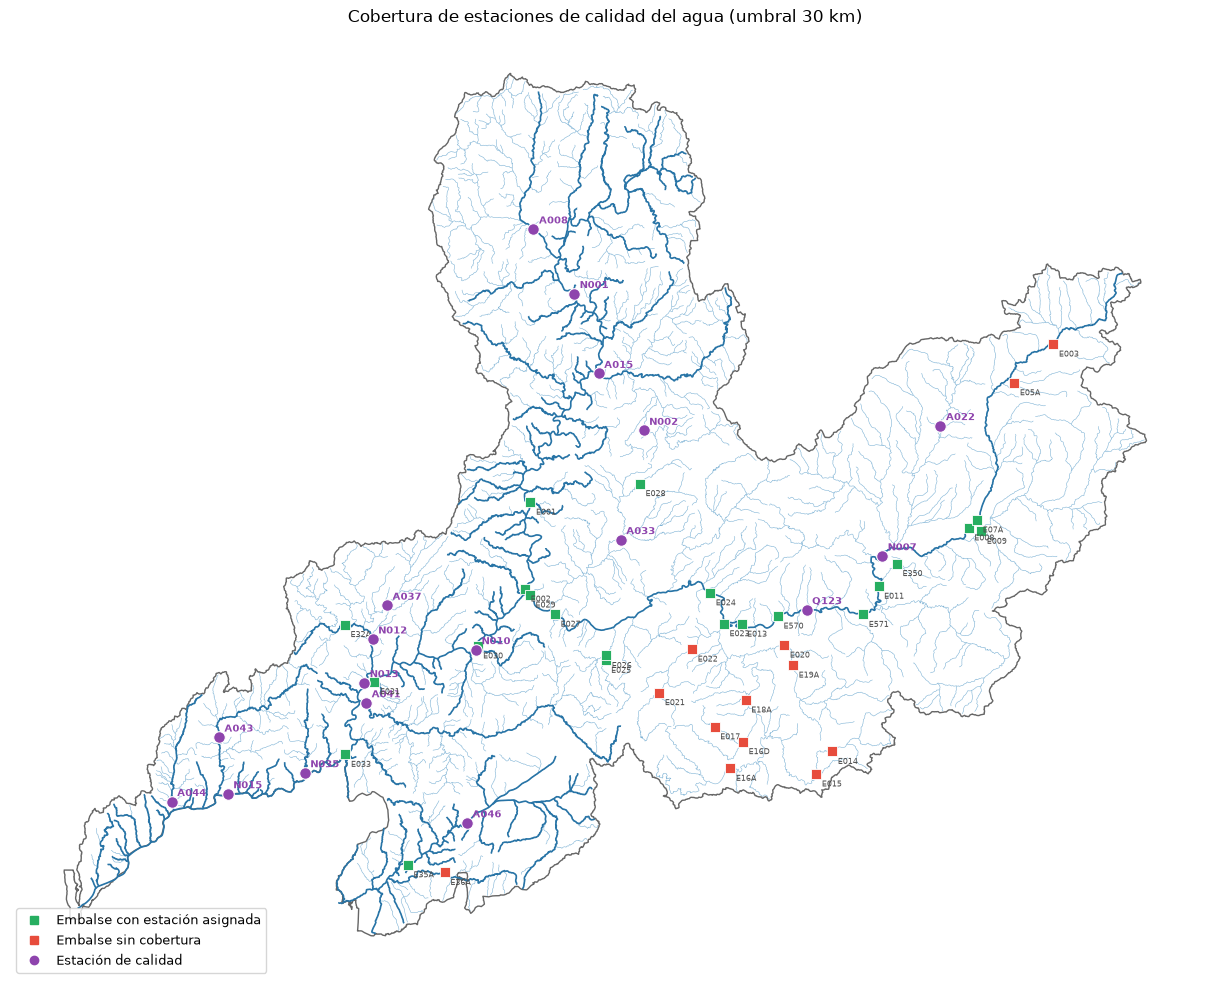

In [15]:
demarcacion = gpd.read_file(DIR_CARTO / "Division_Administrativa" / "Demarcacion_MiñoSil.shp").to_crs(CRS_PROYECTO)
principales = cauces[cauces["CODPK"].str.count("-") <= 2]

cubiertos = set(asignacion["ID_emb"])
emb_plot = embalses_gdf.assign(cubierto=embalses_gdf["ID"].isin(cubiertos))

fig, ax = plt.subplots(figsize=(14, 10))
demarcacion.boundary.plot(ax=ax, color="0.4", linewidth=1)
cauces.plot(ax=ax, color="#7fb3d5", linewidth=0.4, zorder=1)
principales.plot(ax=ax, color="#2874a6", linewidth=1.2, zorder=2)

emb_plot[~emb_plot["cubierto"]].plot(ax=ax, color="#e74c3c", marker="s", markersize=45,
                                     zorder=3, edgecolor="white", linewidth=0.6)
emb_plot[emb_plot["cubierto"]].plot(ax=ax, color="#27ae60", marker="s", markersize=45,
                                    zorder=3, edgecolor="white", linewidth=0.6)
calidad_gdf.plot(ax=ax, color="#8e44ad", marker="o", markersize=70,
                 zorder=4, edgecolor="white", linewidth=0.8)

for _, r in calidad_gdf.iterrows():
    ax.annotate(r["ID"], (r.geometry.x, r.geometry.y), xytext=(4, 4),
                textcoords="offset points", fontsize=7, color="#8e44ad", weight="bold")
for _, r in emb_plot.iterrows():
    ax.annotate(r["ID"], (r.geometry.x, r.geometry.y), xytext=(4, -9),
                textcoords="offset points", fontsize=6, color="0.3")

ax.legend(handles=[
    Line2D([], [], color="#27ae60", marker="s", ls="", label="Embalse con estación asignada"),
    Line2D([], [], color="#e74c3c", marker="s", ls="", label="Embalse sin cobertura"),
    Line2D([], [], color="#8e44ad", marker="o", ls="", label="Estación de calidad"),
], loc="lower left", fontsize=9)

ax.set_title(f"Cobertura de estaciones de calidad del agua (umbral {UMBRAL_KM} km)")
ax.set_axis_off()
fig.tight_layout()
fig.savefig(DIR_FIGURAS / "5_2_cobertura_calidad_embalses.png", dpi=150, bbox_inches="tight")
plt.show()

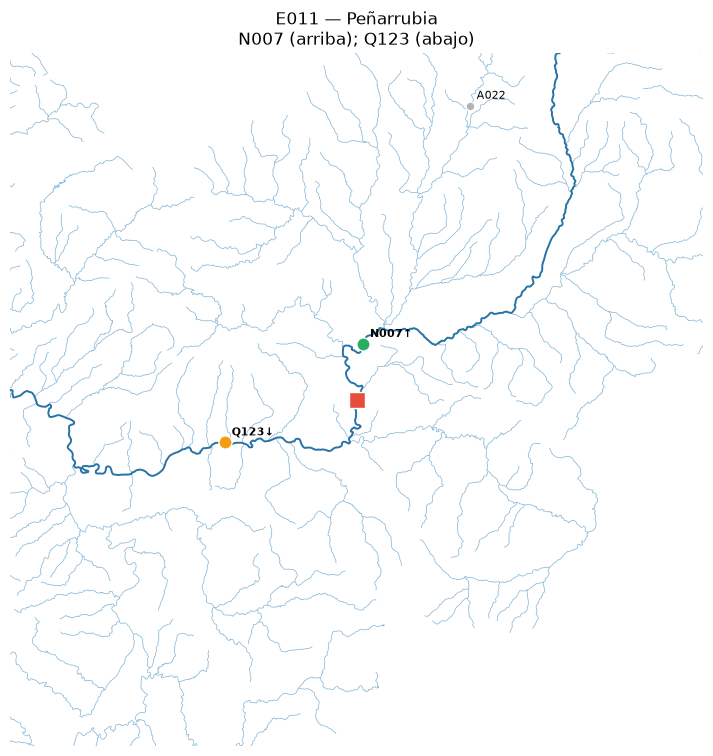

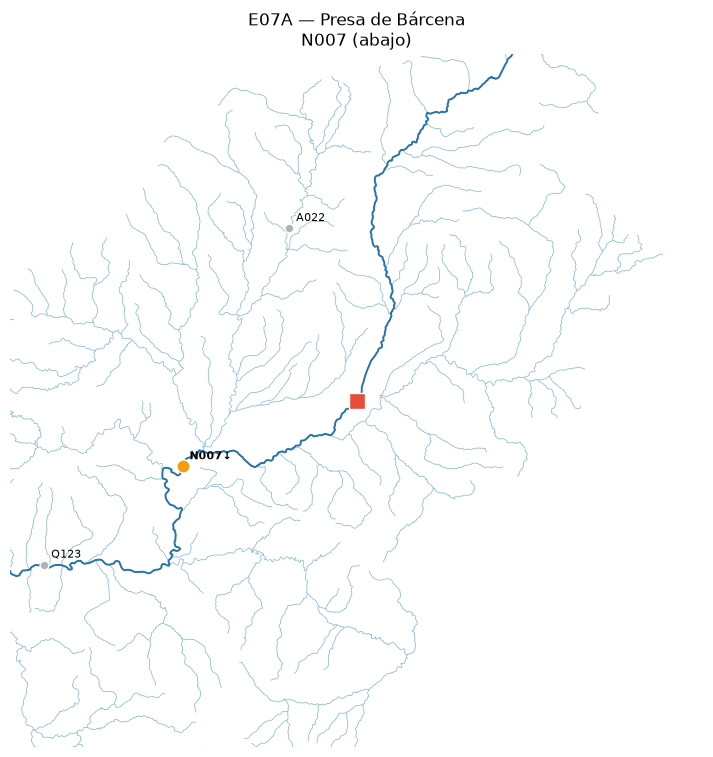

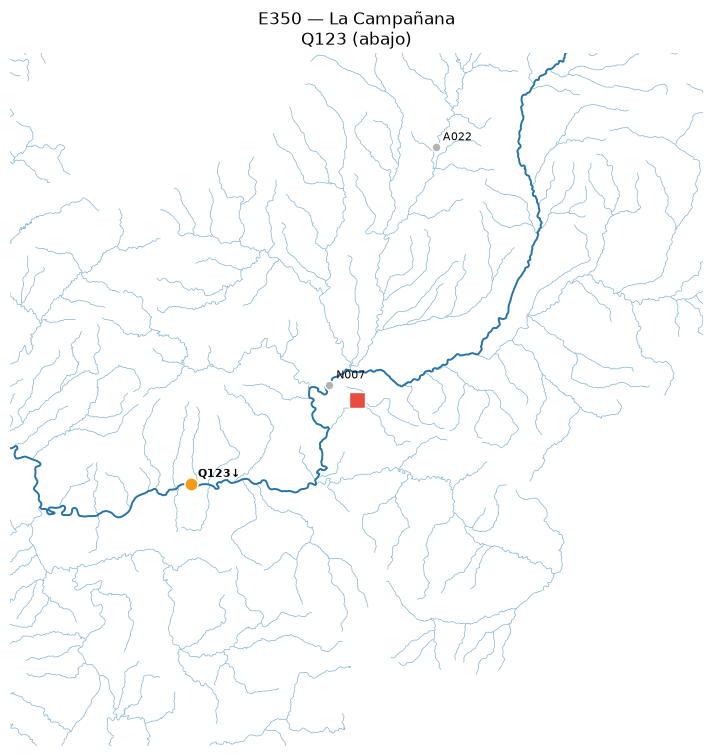

In [16]:
def plot_embalse(id_emb, margen_km=40):
    """Detalle de un embalse y las estaciones de calidad de su entorno."""
    emb = embalses_gdf[embalses_gdf["ID"] == id_emb].iloc[0]
    asignadas = dict(zip(asignacion.loc[asignacion["ID_emb"] == id_emb, "ID_cal"],
                         asignacion.loc[asignacion["ID_emb"] == id_emb, "relacion"]))
    m = margen_km * 1000

    fig, ax = plt.subplots(figsize=(9, 9))
    cauces.plot(ax=ax, color="#7fb3d5", linewidth=0.5)
    principales.plot(ax=ax, color="#2874a6", linewidth=1.4)
    ax.scatter(emb.geometry.x, emb.geometry.y, c="#e74c3c", marker="s", s=140,
               edgecolor="white", zorder=5)

    for _, r in calidad_gdf.iterrows():
        rel = asignadas.get(r["ID"])
        ax.scatter(r.geometry.x, r.geometry.y,
                   c={"arriba": "#27ae60", "abajo": "#f39c12"}.get(rel, "0.7"),
                   marker="o", s=90 if rel else 40, edgecolor="white", zorder=4)
        etiqueta = f"{r['ID']}{'↑' if rel == 'arriba' else '↓' if rel == 'abajo' else ''}"
        ax.annotate(etiqueta, (r.geometry.x, r.geometry.y), xytext=(5, 5),
                    textcoords="offset points", fontsize=8, weight="bold" if rel else "normal")

    ax.set_xlim(emb.geometry.x - m, emb.geometry.x + m)
    ax.set_ylim(emb.geometry.y - m, emb.geometry.y + m)
    ax.set_title(f"{id_emb} — {emb['Nombre']}\n"
                 f"{'; '.join(f'{k} ({v})' for k, v in asignadas.items()) or 'sin cobertura'}")
    ax.set_axis_off()
    fig.savefig(DIR_FIGURAS / f"5_2_asignacion_calidad_embalse_{id_emb}.png", dpi=150, bbox_inches="tight")
    plt.show()

# Casos de control: relaciones que los criterios descartados resolvían mal
plot_embalse("E011")   # Peñarrubia: N007 aguas arriba, Q123 aguas abajo
plot_embalse("E07A")   # Bárcena: N007 aguas abajo; el Cua entra al Sil por debajo
plot_embalse("E350")   # La Campañana: N007 a 3,5 km pero sin conexión de drenaje

## 10. Conclusiones


In [17]:
maestro = pd.read_parquet(DIR_PROCESSED / "maestro_embalses.parquet")
print(f"Embalses en el maestro: {len(maestro)}")

emb_raw = pd.read_excel(DIR_RAW / "saih" / "Datos_Embalses.xlsx",
                        sheet_name="Datos_Embalses", skiprows=[1, 2])
emb_raw = emb_raw.rename(columns={emb_raw.columns[0]: "fecha"})

# Columnas de volumen (contempla las tres variantes de código)
VOLUMEN = {"MACVEMBA", "MAIVEMBA", "ACVEMBA"}
cols_vol = {c: id_estacion(c) for c in emb_raw.columns[1:]
            if PATRON_COL.match(str(c).strip())
            and PATRON_COL.match(str(c).strip()).group(2).upper() in VOLUMEN}

largo = (emb_raw[["fecha"] + list(cols_vol)]
         .melt(id_vars="fecha", var_name="col", value_name="volumen_hm3")
         .assign(id_datos=lambda d: d["col"].map(cols_vol))
         .dropna(subset=["volumen_hm3"]))

# Normalizar al identificador del maestro (E016A -> E16A)
largo["ID_SAIH"] = largo["id_datos"].apply(
    lambda x: x if x in set(maestro["ID_SAIH"]) else normalizar_id_embalse(x))

llenado = (largo.merge(maestro[["ID_SAIH", "Capacidad_hm3"]], on="ID_SAIH", how="inner")
           .assign(pct=lambda d: d["volumen_hm3"] / d["Capacidad_hm3"] * 100))

print(f"Embalses con serie de llenado: {llenado['ID_SAIH'].nunique()}")

stats = llenado.groupby("ID_SAIH")["pct"].agg(
    mediana="median", p10=lambda s: s.quantile(0.10), p90=lambda s: s.quantile(0.90))
stats["rango_p10_p90"] = stats["p90"] - stats["p10"]
stats = stats.join(maestro.set_index("ID_SAIH")["Capacidad_hm3"])
cubiertos = set(asignacion["ID_emb"])
stats["cubierto"] = stats.index.isin(cubiertos)

print()
print(stats.groupby("cubierto")[["Capacidad_hm3", "mediana", "rango_p10_p90"]]
      .median().round(1).to_string())
print()
print(stats.sort_values("rango_p10_p90", ascending=False).round(1).to_string())

Embalses en el maestro: 35
Embalses con serie de llenado: 35

          Capacidad_hm3  mediana  rango_p10_p90
cubierto                                       
False              60.6     56.1           42.7
True               12.9     76.5           19.7

         mediana   p10    p90  rango_p10_p90  Capacidad_hm3  cubierto
ID_SAIH                                                              
E003        49.4  10.6   93.7           83.1           28.0     False
E021        51.2  22.2   95.4           73.2           60.6     False
E028        55.3  25.3   93.8           68.4           20.5      True
E026        41.2  23.8   89.5           65.8           10.7      True
E017        60.1  21.5   87.2           65.7           43.0     False
E001        61.5  26.2   90.4           64.1          645.6      True
E05A        54.0  23.3   82.2           58.9           65.0     False
E16A        75.1  37.6   94.3           56.7          535.7     False
E07A        62.9  30.7   86.7           56.0 